# Model Development and Evaluation

## Objectives

The objectives of this notebook are to:

- Load the engineered housing dataset.
- Prepare categorical and numerical features for modelling.
- Split the data into training and test sets.
- Train and evaluate multiple regression models.
- Compare model performance using consistent metrics.
- Select and save the best-performing model.

---

## Inputs

- Engineered dataset: `engineered_house_prices.csv`

---

## Outputs

This notebook produces:

- Performance metrics for several regression models.
- Visualisations of model predictions and residuals.
- A justified final model selection.
- A trained model and feature list saved for use in the dashboard.

In [86]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    cross_val_score,
    train_test_split,
)

## Load the Engineered Dataset

The engineered dataset is loaded from the previous notebook. Initial checks confirm that the expected features are present and that the dataset is ready for model development.

In [87]:
df = pd.read_csv("../outputs/engineered_house_prices.csv")

df.head()

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice,TotalLivingArea,HouseAge,TotalPorchSF,HasGarage,HasSecondFloor
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,856,0.0,2003,2003,208500,2566,0,61.0,1,1
1,1262,0.0,3.0,Gd,978,ALQ,284,0.0,460,RFn,...,1262,0.0,1976,1976,181500,2524,0,0.0,1,0
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,920,0.0,2001,2002,223500,2706,1,42.0,1,1
3,961,0.0,3.0,No,216,ALQ,540,0.0,642,Unf,...,756,0.0,1915,1970,140000,2473,55,35.0,1,0
4,1145,0.0,4.0,Av,655,GLQ,490,0.0,836,RFn,...,1145,0.0,2000,2000,250000,3343,0,84.0,1,0


### Dataset Shape

In [88]:
df.shape

(1460, 29)

### Dataset Information

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   1stFlrSF         1460 non-null   int64  
 1   2ndFlrSF         1460 non-null   float64
 2   BedroomAbvGr     1460 non-null   float64
 3   BsmtExposure     1460 non-null   object 
 4   BsmtFinSF1       1460 non-null   int64  
 5   BsmtFinType1     1460 non-null   object 
 6   BsmtUnfSF        1460 non-null   int64  
 7   EnclosedPorch    1460 non-null   float64
 8   GarageArea       1460 non-null   int64  
 9   GarageFinish     1460 non-null   object 
 10  GarageYrBlt      1460 non-null   float64
 11  GrLivArea        1460 non-null   int64  
 12  KitchenQual      1460 non-null   object 
 13  LotArea          1460 non-null   int64  
 14  LotFrontage      1460 non-null   float64
 15  MasVnrArea       1460 non-null   float64
 16  OpenPorchSF      1460 non-null   int64  
 17  OverallCond   

## Encode Categorical Variables

Machine learning estimators require numerical inputs. Categorical variables are converted into dummy variables using one-hot encoding.

The first category from each variable is dropped to reduce redundant information and avoid perfect multicollinearity.

In [90]:
df = pd.get_dummies(df, drop_first=True)

In [91]:
df.shape

(1460, 38)

## Split Features and Target

`SalePrice` is the target variable. All remaining columns are used as potential predictors.

In [92]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (1460, 37)
Target shape: (1460,)


## Train-Test Split

The data is divided into training and test sets.

- 80% is used to train the models.
- 20% is reserved for final evaluation.
- A fixed random state ensures reproducible results.

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 37)
(292, 37)


## Candidate Regression Models

Several regression algorithms are evaluated using the same training and test data:

- Linear Regression provides an interpretable baseline.
- Ridge Regression adds regularisation to reduce sensitivity to correlated features.
- Random Forest can capture non-linear relationships and feature interactions.
- Gradient Boosting builds a sequence of models that progressively correct prediction errors.

In [94]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
    ),
}

In [95]:
model_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)
    mae = mean_absolute_error(y_test, test_predictions)
    rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
    )

    model_results.append(
        {
            "Model": model_name,
            "Training R2": train_r2,
            "Test R2": test_r2,
            "MAE": mae,
            "RMSE": rmse,
            "Cross-Validation R2": cv_scores.mean(),
        }
    )

    trained_models[model_name] = model

In [96]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Cross-Validation R2",
    ascending=False,
).reset_index(drop=True)

results_df.round(4)

,Model,Training R2,Test R2,MAE,RMSE,Cross-Validation R2
0,Gradient Boosting,0.9633,0.8892,17953.9696,29149.1280,0.8607
1,Random Forest,0.9797,0.8856,18297.3298,29619.4862,0.8438
2,Ridge Regression,0.8141,0.8476,21236.1568,34187.6451,0.7747
3,Linear Regression,0.8141,0.8477,21242.8244,34178.3601,0.7746


### Model Comparison

The comparison table summarises the performance of each regression algorithm.

The final model was selected using cross-validation performance together with the test-set metrics. This approach reduces the likelihood of selecting a model that performs well only on a single train-test split and provides greater confidence that the model will generalise to unseen data.

## Evaluation Metrics

The models are compared using:

- **Mean Absolute Error:** the average absolute difference between actual and predicted prices.
- **Root Mean Squared Error:** gives greater weight to large prediction errors.
- **R²:** the proportion of variation in sale prices explained by the model.
- **Cross-validation R²:** the average R² across five training-data folds, providing a more robust estimate of generalisation performance.

Lower MAE and RMSE values are preferable, while higher R² values are preferable.

In [97]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print(f"Selected model: {best_model_name}")

Selected model: Gradient Boosting


In [98]:
selected_model_results = results_df.loc[
    results_df["Model"] == best_model_name
]

selected_model_results.round(4)

,Model,Training R2,Test R2,MAE,RMSE,Cross-Validation R2
0,Gradient Boosting,0.9633,0.8892,17953.9696,29149.128,0.8607


In [99]:
best_predictions = best_model.predict(X_test)

### Final Model Selection

The model shown above was selected primarily because it achieved the highest mean cross-validation R² score.

Its training and test R² scores, MAE and RMSE were also reviewed to confirm that its performance was consistent and that there was no strong evidence of overfitting.

This provides a clearer and more reliable justification for selecting the model for deployment.

## Actual vs Predicted Plot

The scatter plot compares the actual sale prices with the prices predicted by the selected regression model.

Points close to the diagonal reference line indicate accurate predictions, while points further away represent larger prediction errors.

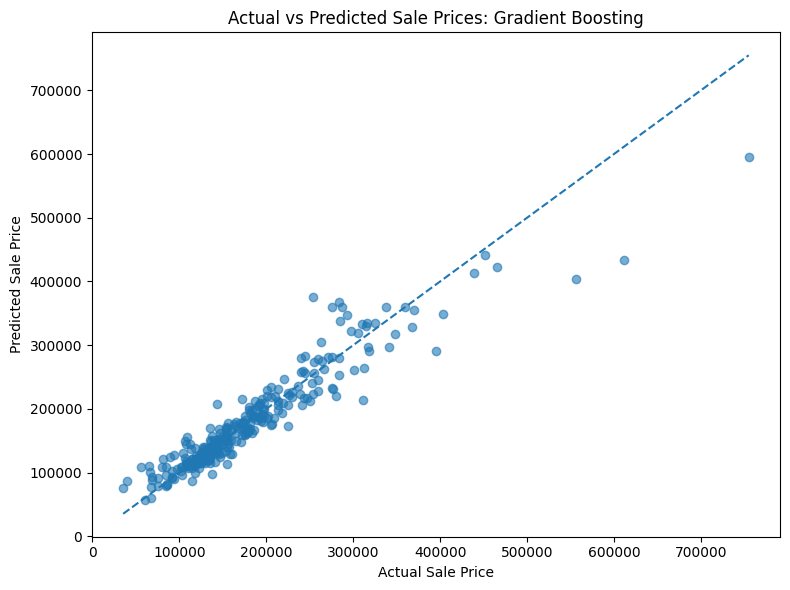

In [100]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, best_predictions, alpha=0.6)

minimum = min(y_test.min(), best_predictions.min())
maximum = max(y_test.max(), best_predictions.max())

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
)

ax.set_xlabel("Actual Sale Price")
ax.set_ylabel("Predicted Sale Price")
ax.set_title(f"Actual vs Predicted Sale Prices: {best_model_name}")

plt.tight_layout()

plt.savefig(
    "../outputs/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Actual vs Predicted Interpretation

Most predicted values are positioned close to the diagonal reference line, showing that the selected regression model produces reasonably accurate estimates for the majority of properties.

The model performs particularly well for houses in the lower and middle price ranges. Some higher-priced properties remain more difficult to predict, resulting in a small number of larger prediction errors.

The training, test and cross-validation scores are considered together when selecting the final model, helping ensure that it generalises well to unseen data.

## Residual Analysis

Residuals represent the difference between actual and predicted sale prices.

A well-performing regression model should produce residuals that are distributed around zero without a strong systematic pattern.

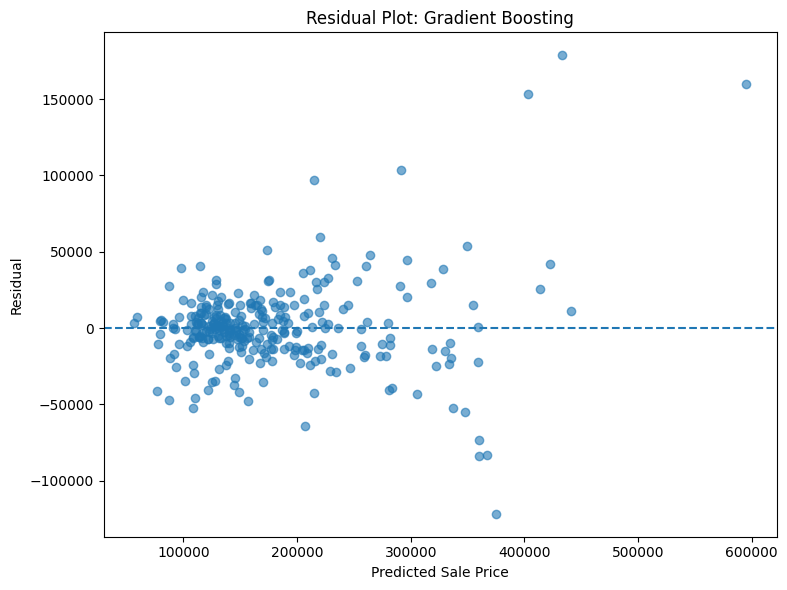

In [101]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 6))

plt.scatter(best_predictions, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")
plt.title(f"Residual Plot: {best_model_name}")

plt.tight_layout()
plt.show()

The residual plot is inspected for systematic patterns.

Residuals positioned around zero indicate relatively accurate predictions. Larger residuals at higher predicted prices may indicate that expensive properties remain more difficult to estimate. Any visible curve or funnel pattern would suggest that the model does not fully capture the underlying relationship or that prediction errors increase with property value.

## Conclusion

Four regression models were trained and evaluated:

- Linear Regression
- Ridge Regression
- Random Forest
- Gradient Boosting

Each model was assessed using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- Five-fold Cross-Validation R²

The model with the strongest overall performance was selected for deployment in the Streamlit dashboard.

The comparison demonstrates that evaluating multiple algorithms provides a more reliable basis for model selection than relying on a single regression model.

## Model Limitations

Although the selected regression model achieved good predictive performance, several limitations remain:

- Some higher-priced properties show larger prediction errors, indicating that these properties may be more difficult for the selected model to estimate accurately.
- The model may be influenced by outliers in features such as living area and sale price.
- The dashboard collects only a selected group of property characteristics. Remaining model features are filled with typical values from the training dataset.
- The model was trained using historical housing data from Ames, Iowa, and may not generalise to other locations or future market conditions.
- Model performance may change when the model is applied to properties that differ substantially from those in the training dataset.

## Retrain the Selected Model

After model selection and test-set evaluation, the selected algorithm is retrained using the complete dataset.

This allows the deployed model to learn from all available property records. The test-set results reported earlier remain the independent estimate of model performance.

In [102]:
final_model = models[best_model_name]
final_model.fit(X, y)

print(f"{best_model_name} retrained using the complete dataset.")

Gradient Boosting retrained using the complete dataset.


## Recommendations for Future Work

Future improvements could include:

- Tuning the selected model's hyperparameters using `GridSearchCV`.
- Investigating additional regression algorithms such as XGBoost or LightGBM.
- Testing transformations of the SalePrice target to reduce the effect of skewness and expensive outliers.
- Expanding the prediction form to collect more property characteristics.
- Comparing model performance before and after feature engineering.
- Retraining the model with newer housing-market data.

## Save the Final Model

The retrained model, feature list and selected model name are saved for use in the Streamlit dashboard.

In [103]:
os.makedirs("../outputs/models", exist_ok=True)

joblib.dump(
   final_model,
    "../outputs/models/best_regression_model.pkl",
)

joblib.dump(
    X.columns.tolist(),
    "../outputs/models/model_features.pkl",
)

joblib.dump(
    best_model_name,
    "../outputs/models/model_name.pkl",
)

print("Selected model and feature list saved successfully.")

Selected model and feature list saved successfully.
